Generating LangGraph Execution Flowchart...


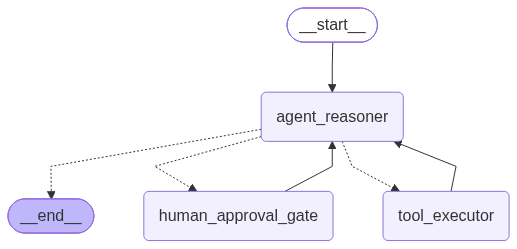


--- Starting Agent Execution ---
Node Executed: agent_reasoner
Message: 

Node Executed: tool_executor
Message: Work Orders for today: WO-101 (Running), WO-102 (Pending).

Node Executed: agent_reasoner
Message: I have compiled the report. Awaiting human approval.


--- HUMAN APPROVAL REQUIRED ---
Agent wants to submit the daily operations report.
Human Action: Approved
-------------------------------

Node Executed: human_approval_gate
Node Executed: agent_reasoner
Message: Report submitted successfully.



In [1]:
# ---------------------------------------------------------
# 02_Daily_Ops_Reporting_Agent.ipynb
# LangGraph Implementation for MES Daily Operations
# ---------------------------------------------------------

import operator
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display

# 1. Define the Graph State
# This tracks the conversation and the workflow step across nodes
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    requires_approval: bool
    approval_status: str # Matches workflow_history approval_status[cite: 5]
    next_step: str

# 2. Mocking the MES Tools (In reality, these map to backend_api_table)
def fetch_work_orders(date: str) -> str:
    """Fetches the scheduled work orders for the given date."""
    return f"Work Orders for {date}: WO-101 (Running), WO-102 (Pending)."

def check_machine_status(machine_id: str) -> str:
    """Checks the live SCADA/MES status of a machine."""
    return f"Machine {machine_id}: Offline (Maintenance)."

# 3. Define the Nodes
def agent_reasoner(state: AgentState):
    """
    Node 1: The LLM Reasoner.
    It looks at the context and decides whether to call a tool, 
    ask for human approval, or finish the report.
    """
    messages = state['messages']
    
    # Mock LLM Logic: If this is the first message, decide to fetch data
    if len(messages) == 1:
        # LLM decides to use a tool
        response = AIMessage(
            content="",
            tool_calls=[{"name": "fetch_work_orders", "args": {"date": "today"}, "id": "call_abc123"}]
        )
        return {"messages": [response], "next_step": "execute_tool"}
    
    # Mock LLM Logic: If data is gathered, compile the report and ask for approval
    elif len(messages) > 1 and state.get('approval_status') == 'Pending':
        return {"messages": [AIMessage(content="I have compiled the report. Awaiting human approval.")], "next_step": "human_approval"}
    
    # Final state
    elif state.get('approval_status') == 'Approved':
        return {"messages": [AIMessage(content="Report submitted successfully.")], "next_step": "end"}

def tool_executor(state: AgentState):
    """
    Node 2: Tool Execution.
    Executes the specific MES API authorized in pipeline_step_apis[cite: 5].
    """
    # Extract the tool call from the last AI message
    last_message = state['messages'][-1]
    tool_call = last_message.tool_calls[0]
    
    # Execute the mock tool
    if tool_call['name'] == "fetch_work_orders":
        result = fetch_work_orders(tool_call['args']['date'])
        
    tool_message = ToolMessage(content=result, tool_call_id=tool_call['id'])
    
    # Set the state to require approval before sending the final report
    return {"messages": [tool_message], "approval_status": "Pending", "next_step": "agent"}

def human_approval_gate(state: AgentState):
    """
    Node 3: Human-in-the-Loop (HITL).
    Pauses execution. In production, this updates workflow_history[cite: 5] 
    and waits for portal interaction.
    """
    print("\n--- HUMAN APPROVAL REQUIRED ---")
    print("Agent wants to submit the daily operations report.")
    
    # Simulating a user clicking "Approve" on the frontend
    user_input = "Approved" # In reality, this comes from the UI/Database
    
    print(f"Human Action: {user_input}\n-------------------------------\n")
    return {"approval_status": user_input, "next_step": "agent"}

# 4. Define the Routing Logic
def route_next_step(state: AgentState):
    """Determines which node to execute next based on the state."""
    step = state.get("next_step")
    if step == "execute_tool":
        return "tool_executor"
    elif step == "human_approval":
        return "human_approval_gate"
    elif step == "end":
        return END
    return "agent_reasoner"

# 5. Build the LangGraph
workflow = StateGraph(AgentState)

# Add Nodes
workflow.add_node("agent_reasoner", agent_reasoner)
workflow.add_node("tool_executor", tool_executor)
workflow.add_node("human_approval_gate", human_approval_gate)

# Add Edges
workflow.add_edge(START, "agent_reasoner")

# Add Conditional Edges from the reasoner
workflow.add_conditional_edges(
    "agent_reasoner",
    route_next_step,
    {
        "tool_executor": "tool_executor",
        "human_approval_gate": "human_approval_gate",
        END: END
    }
)

# Loop back to reasoner after tool execution or approval
workflow.add_edge("tool_executor", "agent_reasoner")
workflow.add_edge("human_approval_gate", "agent_reasoner")

# Compile the graph
app = workflow.compile()

# 6. Render the Graph Visualization
# This will display the Mermaid flowchart directly in your Jupyter Notebook
print("Generating LangGraph Execution Flowchart...")
display(Image(app.get_graph().draw_mermaid_png()))

# 7. Test the Pipeline Execution
print("\n--- Starting Agent Execution ---")
initial_state = {
    "messages": [HumanMessage(content="Generate the daily operations report for today.")],
    "requires_approval": True,
    "approval_status": "None",
    "next_step": ""
}

# Run the graph
for output in app.stream(initial_state):
    for key, value in output.items():
        print(f"Node Executed: {key}")
        if "messages" in value:
            print(f"Message: {value['messages'][-1].content}\n")